In [1]:
%load_ext autoreload
%autoreload 2

In [26]:
import os
import copy

import albumentations as A
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.models as models
from albumentations.pytorch import ToTensorV2
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from torch.amp import autocast, GradScaler
from torch.utils.data import DataLoader
from torchvision import transforms

from custom_datasets import CBISDDSM_ResNet_Dataset
from util import create_dataframes, pair_images, get_model_file_path

In [3]:
df, full_mammograms_df, roi_masks_df, cropped_df = create_dataframes()

print(f"Total ROIs: {len(roi_masks_df)}")
print(roi_masks_df['image_path'].head(5))

Total ROIs: 1696
5     ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
10    ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
12    ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
18    ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
19    ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
Name: image_path, dtype: str


In [4]:
paired_df, merged_df = pair_images(roi_masks_df, full_mammograms_df)

Successfully paired 1696 mammogram/ROI pairs.
Removed 78 entries due to mismatched dimensions.
Consolidated into 1514 image entries.


In [5]:
cropped_df = cropped_df[cropped_df['PatientID'].isin(merged_df['PatientID_roi'])]

In [6]:
train_transform = A.Compose(
    [
        A.Resize(256, 256),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
            max_pixel_value=255.0,
        ),
        ToTensorV2(),
    ]
)

test_transform = A.Compose(
    [
        A.Resize(256, 256),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
            max_pixel_value=255.0,
        ),
        ToTensorV2(),
    ]
)

inv_transform = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
)

In [7]:
dataset = CBISDDSM_ResNet_Dataset(dataframe=cropped_df)

transformed_dataset = CBISDDSM_ResNet_Dataset(dataframe=cropped_df, transform=test_transform)

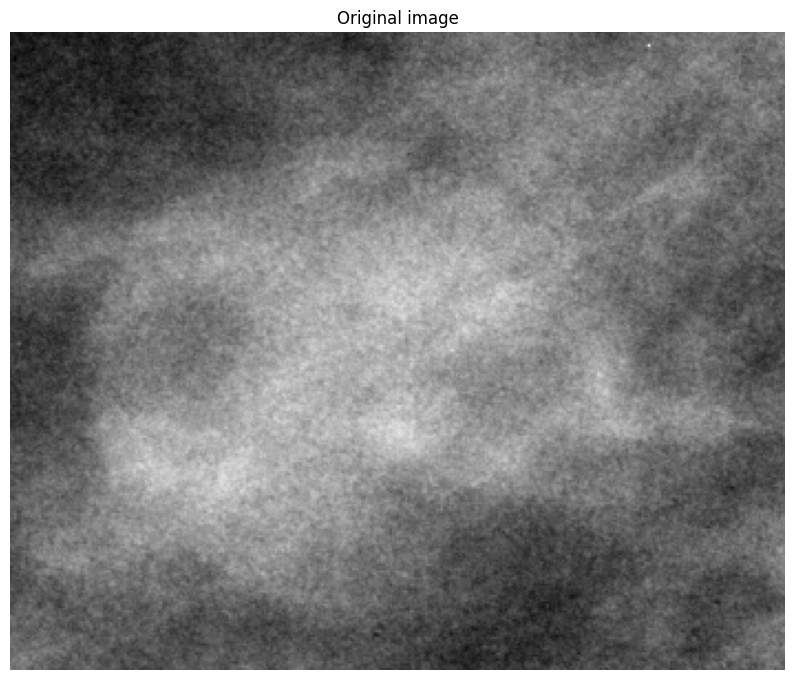

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9980307..2.117124].


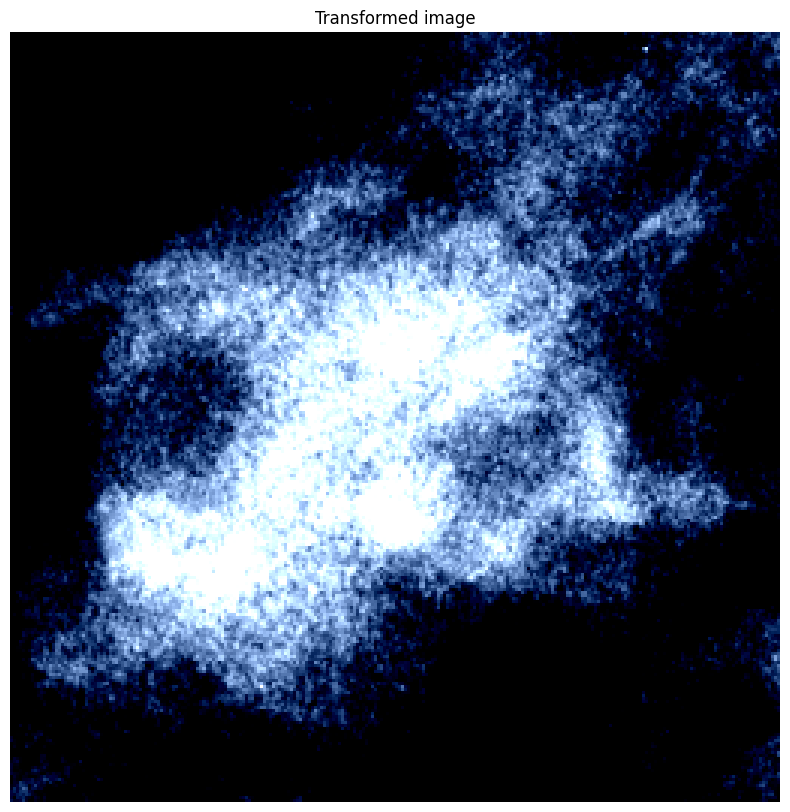

In [8]:
dataset.visualize_sample(0, "Original image")

transformed_dataset.visualize_sample(0, "Transformed image")

# Train test split

In [9]:
train_df, test_df = train_test_split(cropped_df, test_size=0.2, random_state=42)

In [10]:
train_dataset = CBISDDSM_ResNet_Dataset(dataframe=train_df, transform=train_transform)

test_dataset = CBISDDSM_ResNet_Dataset(dataframe=test_df, transform=test_transform)

In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    pin_memory=True,
)

# Initialize model and check for cuda

In [24]:
def get_model(num_classes):
    m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    for param in m.parameters():
        param.requires_grad = False

    for param in m.layer4.parameters():
        param.requires_grad = True
    for param in m.layer3.parameters():
        param.requires_grad = True
    for param in m.layer2.parameters():
        param.requires_grad = True

    num_features = m.fc.in_features
    m.fc = nn.Linear(num_features, num_classes)
    return m


num_classes = 2
model = get_model(num_classes)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)
print(f"Using device: {device}")

Using device: cuda


In [13]:
checkpoint_dir = '../models/Resnet/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

completed_dir = '../models/Resnet/completed'
os.makedirs(completed_dir, exist_ok=True)

# Check for trained models

In [14]:
completed_path = None

if len(os.listdir(completed_dir)) > 0:
    completed_path = get_model_file_path("Completed model directory is not empty. Do you want to use saved model? (y/n): ",
                                         "../models/Resnet/completed")

    if completed_path:
        print(f"Using saved model from {completed_path}")
    else:
        print("No model file selected. Starting training from scratch.")

No model file selected. Starting training from scratch.


# Model training

Epoch [1/70], Batch [1/21], Loss: 0.6581
Epoch [1/70], Batch [11/21], Loss: 0.6654
Epoch [1/70], Batch [21/21], Loss: 0.5919
--- Epoch 1 Completed | Train Loss: 37.3407 | Val Loss: 33.1423 ---
Checkpoint saved to ../models/Resnet/checkpoints\checkpoint_1.pth
Epoch [2/70], Batch [1/21], Loss: 0.5463
Epoch [2/70], Batch [11/21], Loss: 0.5491
Epoch [2/70], Batch [21/21], Loss: 0.5346
--- Epoch 2 Completed | Train Loss: 33.6081 | Val Loss: 30.0059 ---
Checkpoint saved to ../models/Resnet/checkpoints\checkpoint_2.pth
Epoch [3/70], Batch [1/21], Loss: 0.5969
Epoch [3/70], Batch [11/21], Loss: 0.4764
Epoch [3/70], Batch [21/21], Loss: 0.4117
--- Epoch 3 Completed | Train Loss: 30.6539 | Val Loss: 27.2590 ---
Checkpoint saved to ../models/Resnet/checkpoints\checkpoint_3.pth
Epoch [4/70], Batch [1/21], Loss: 0.5114
Epoch [4/70], Batch [11/21], Loss: 0.3984
Epoch [4/70], Batch [21/21], Loss: 0.5560
--- Epoch 4 Completed | Train Loss: 27.9496 | Val Loss: 27.3908 ---
Checkpoint saved to ../models/

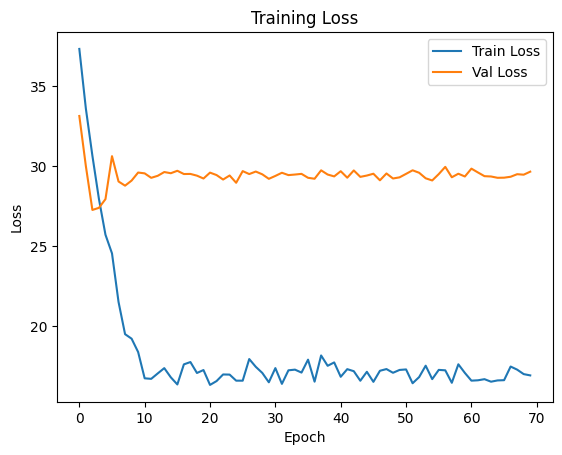

In [27]:
params = [p for p in model.parameters() if p.requires_grad]

class_weights = torch.tensor([1.0, 3.0]).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(params, lr=0.0001)

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

num_epochs = 70
start_epoch = 0

loss_history = []
val_loss_history = []
best_epoch = 0
best_val_loss = np.inf
best_model_weights = copy.deepcopy(model.state_dict())

if completed_path:
    if os.path.exists(completed_path):
        print(f"Loading model from {completed_path}")
        saved = torch.load(completed_path, map_location=device)
        model.load_state_dict(saved)
        model.eval()
        print("Model loaded successfully.")
else:
    scaler = GradScaler()
    for epoch in range(start_epoch, num_epochs):
        model.train()
        epoch_loss = 0

        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu', enabled=True):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += loss.item() * images.size(0)

            if i % 10 == 0:
                print(f"Epoch [{epoch + 1}/{num_epochs}], Batch [{i + 1}/{len(train_loader)}], Loss: {loss.item():.4f}")

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for val_images, val_labels in test_loader:
                val_images = val_images.to(device)
                val_labels = val_labels.to(device)
                val_outputs = model(val_images)
                v_loss = criterion(val_outputs, val_labels)
                val_loss += v_loss.item() * val_images.size(0)
        val_loss /= len(test_loader)
        scheduler.step(val_loss)

        print(f"--- Epoch {epoch + 1} Completed | Train Loss: {epoch_loss / len(train_loader):.4f} | Val Loss: {val_loss:.4f} ---")
        loss_history.append(epoch_loss / len(train_loader))
        val_loss_history.append(val_loss)

        if epoch_loss < best_val_loss:
            best_val_loss = epoch_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            best_epoch = epoch

        checkpoint_path = os.path.join(checkpoint_dir, f'checkpoint_{epoch + 1}.pth')
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': epoch_loss
        }
        torch.save(checkpoint, checkpoint_path)
        print(f"Checkpoint saved to {checkpoint_path}")

    model.load_state_dict(best_model_weights)

    # --Write graph code here--
    plt.plot(loss_history, label='Train Loss')
    plt.plot(val_loss_history, label='Val Loss')
    plt.legend()
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.show()

In [28]:
if not completed_path:
    save_path = os.path.join(completed_dir, 'completed.pth')
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to {save_path}")

Model saved to ../models/Resnet/completed\completed.pth


# Testing and Visualization

## Visualization

In [17]:
def test_and_visualize(model, loader, device, num_samples=3):
    model.eval()

    images, labels = next(iter(loader))
    images = images.to(device)

    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    images = images.cpu()
    labels = labels.cpu()
    preds = preds.cpu()

    class_names = ['benign', 'malignant']

    num_to_plot = min(num_samples, images.size(0))
    fig, axes = plt.subplots(1, num_to_plot, figsize=(15, 4))

    if num_to_plot == 1:
        axes = [axes]

    for i in range(num_to_plot):
        ax = axes[i]
        img = inv_transform(images[i])

        img = img.permute(1, 2, 0).numpy()

        img = np.clip(img, 0, 1)

        ax.imshow(img)

        true_label = class_names[labels[i].item()]
        pred_label = class_names[preds[i].item()]

        color = 'green' if preds[i] == labels[i] else 'red'
        ax.set_title(f"True: {true_label}, Pred: {pred_label}", color=color)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

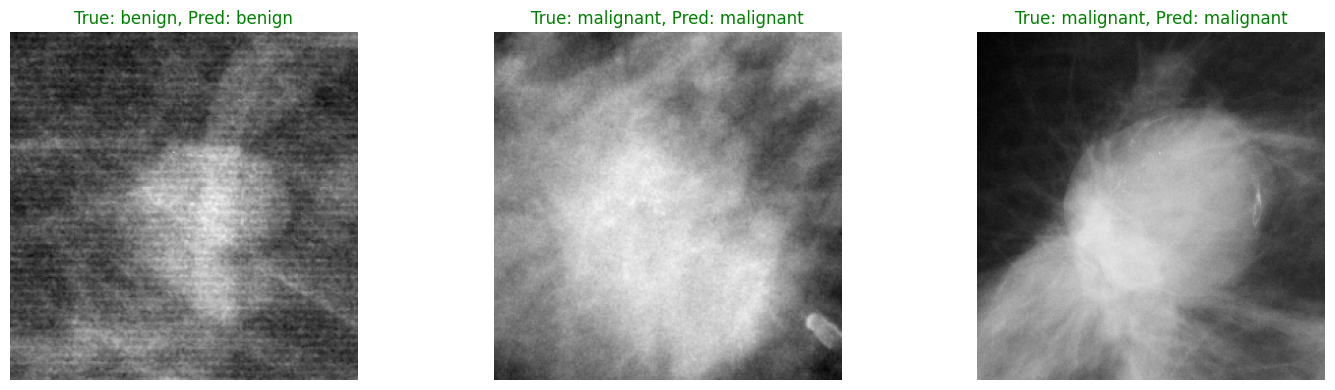

In [18]:
test_and_visualize(model, test_loader, device)

## Evaluation

Validation Loss: 0.5481
Validation Accuracy: 0.7006

Classification Report:
              precision    recall  f1-score   support

      benign       0.74      0.60      0.66       159
   malignant       0.67      0.80      0.73       165

    accuracy                           0.70       324
   macro avg       0.71      0.70      0.70       324
weighted avg       0.71      0.70      0.70       324

Confusion Matrix:


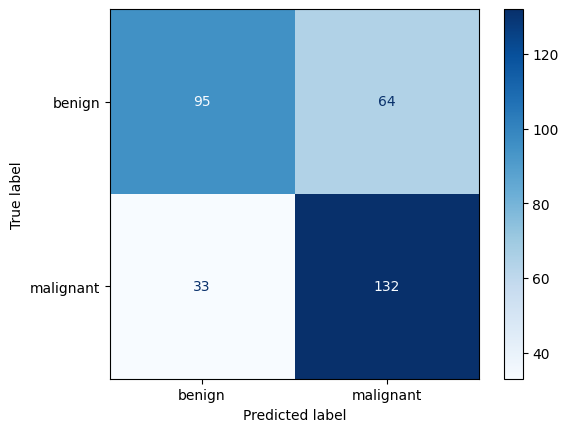

In [29]:
model.eval()

val_running_loss = 0.0
correct_predictions = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        val_running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct_predictions += torch.sum(preds == labels.data).item()
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

val_loss = val_running_loss / len(test_loader.dataset)
val_acc = correct_predictions / len(test_loader.dataset)

print(f'Validation Loss: {val_loss:.4f}')
print(f'Validation Accuracy: {val_acc:.4f}')

print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=['benign', 'malignant']))

print('Confusion Matrix:')
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['benign', 'malignant'])
disp.plot(cmap=plt.cm.Blues)
plt.show()
